# Exploratory Data Analysis

In [6]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving spam.csv.xls to spam.csv (1).xls
User uploaded file "spam.csv (1).xls" with length 503663 bytes


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('spam.csv (1).xls', encoding='latin-1')

# Keep Required Columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Display Dataset
print(df.head())




  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [10]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [11]:
print(df.shape)

(5572, 2)


In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
df = df.drop_duplicates()

In [14]:
df['label'].value_counts()

,count
label,
ham,4516
spam,653


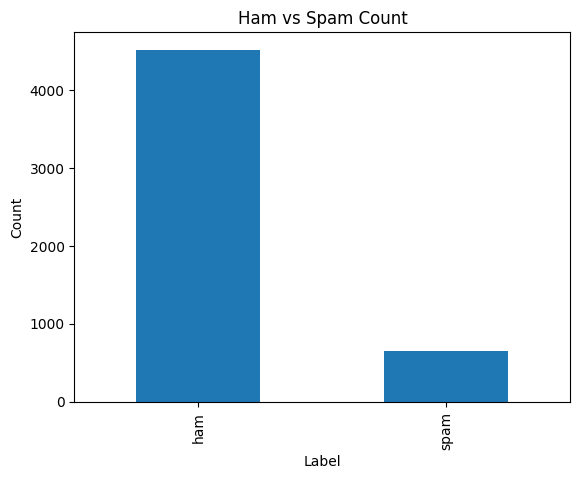

In [15]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Ham vs Spam Count")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [16]:
df['label'].value_counts(normalize=True) * 100

,proportion
label,
ham,87.366996
spam,12.633004


In [17]:
df['message_length'] = df['message'].apply(len)

/tmp/ipykernel_11644/1669308277.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['message_length'] = df['message'].apply(len)


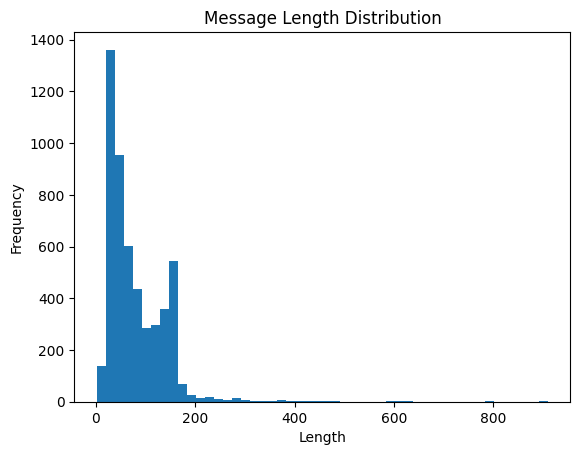

In [18]:
plt.hist(df['message_length'], bins=50)
plt.title("Message Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

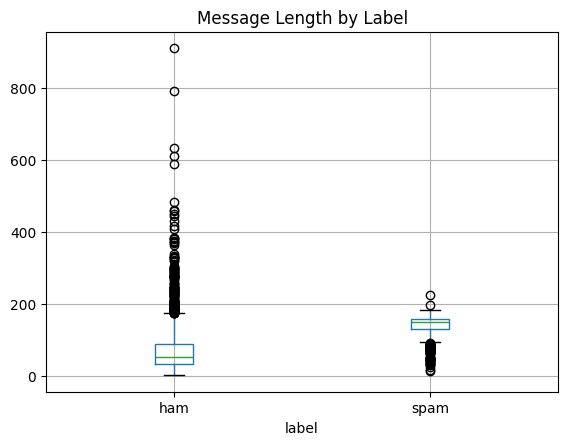

In [19]:
df.boxplot(column='message_length', by='label')
plt.title("Message Length by Label")
plt.suptitle("")
plt.show()

In [20]:
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

/tmp/ipykernel_11644/1686568713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count'] = df['message'].apply(lambda x: len(x.split()))


In [21]:
df.groupby('label')['word_count'].mean()

,word_count
label,
ham,14.134632
spam,23.681470


In [22]:
from collections import Counter

all_words = " ".join(df['message']).split()

common_words = Counter(all_words).most_common(20)

print(common_words)

[('to', 1972), ('you', 1562), ('I', 1375), ('a', 1198), ('the', 1114), ('and', 814), ('in', 731), ('i', 720), ('is', 691), ('u', 614), ('for', 604), ('my', 579), ('me', 532), ('of', 531), ('your', 517), ('have', 447), ('on', 446), ('2', 423), ('that', 407), ('it', 376)]


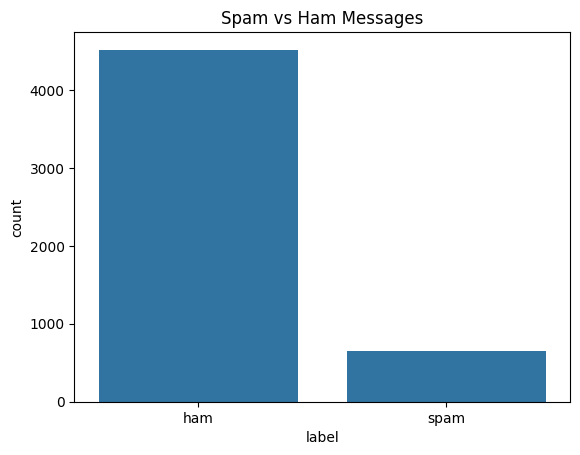

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Messages")
plt.show()

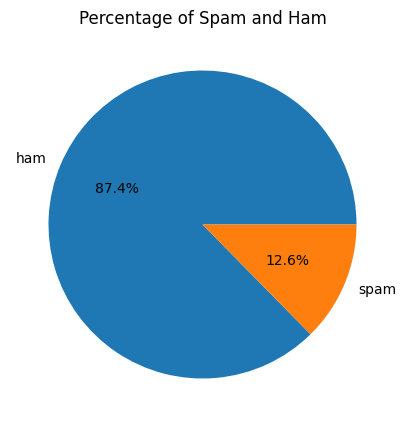

In [25]:
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5)
)

plt.title("Percentage of Spam and Ham")
plt.ylabel("")
plt.show()

/tmp/ipykernel_11644/2556662239.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['message_length'] = df['message'].apply(len)


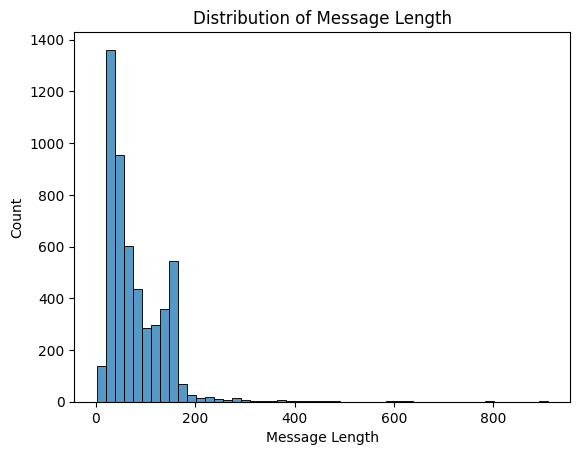

In [26]:
df['message_length'] = df['message'].apply(len)

sns.histplot(df['message_length'], bins=50)

plt.title("Distribution of Message Length")
plt.xlabel("Message Length")
plt.show()

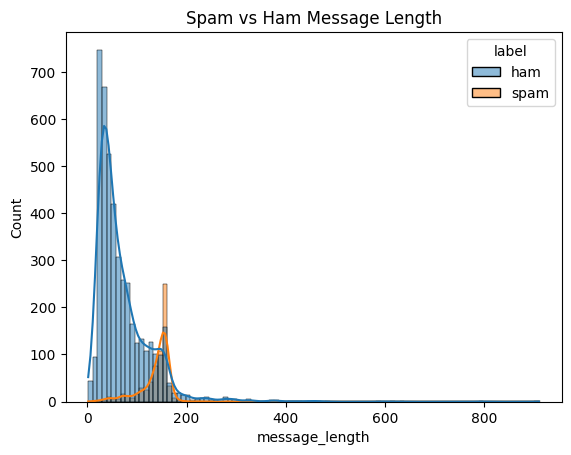

In [27]:
sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    kde=True
)

plt.title("Spam vs Ham Message Length")
plt.show()

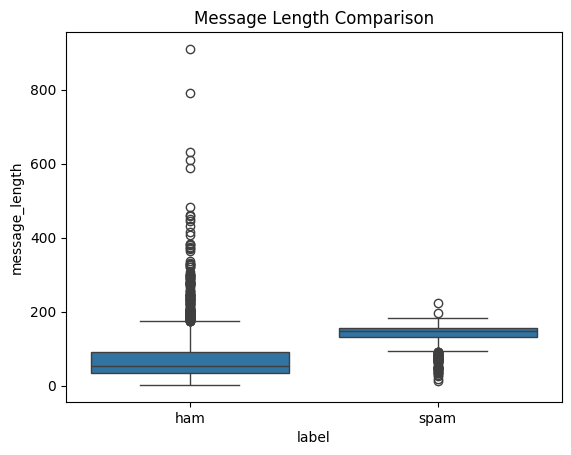

In [28]:
sns.boxplot(x='label', y='message_length', data=df)

plt.title("Message Length Comparison")
plt.show()

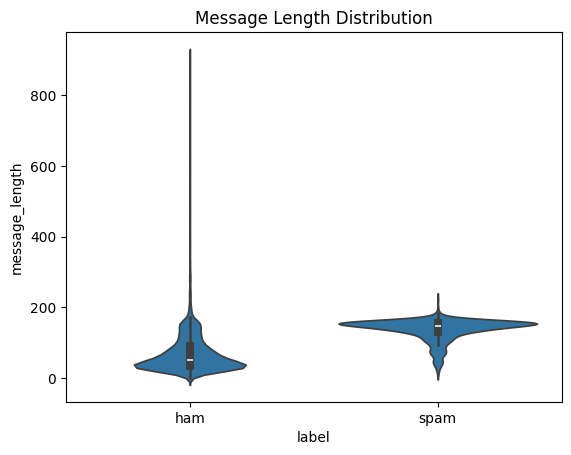

In [29]:
sns.violinplot(x='label', y='message_length', data=df)

plt.title("Message Length Distribution")
plt.show()

/tmp/ipykernel_11644/2810305424.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count'] = df['message'].apply(lambda x: len(x.split()))


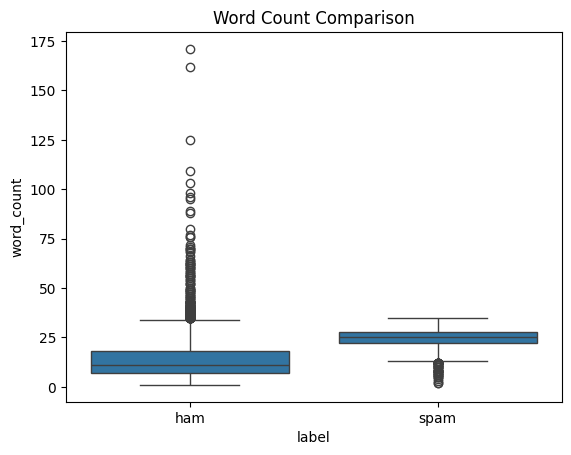

In [30]:
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

sns.boxplot(x='label', y='word_count', data=df)

plt.title("Word Count Comparison")
plt.show()

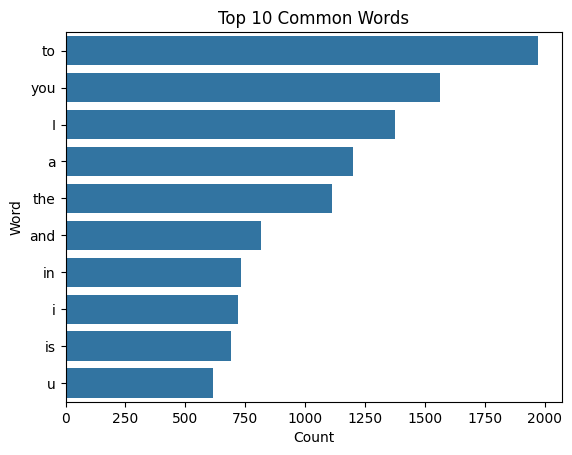

In [31]:
from collections import Counter
import pandas as pd

words = " ".join(df['message']).split()

common_words = Counter(words).most_common(10)

word_df = pd.DataFrame(common_words, columns=['Word', 'Count'])

sns.barplot(x='Count', y='Word', data=word_df)

plt.title("Top 10 Common Words")
plt.show()